In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

base_path = "/content/drive/MyDrive/GDA_Project/"

# Load data
combined = pd.read_csv(base_path + "combined_expression.csv", index_col=0)
combined.index = combined.index.str.upper()

# Remove duplicates (safety)
combined = combined.groupby(combined.index).mean()

deg_filtered = pd.read_csv(base_path + "DEG_filtered.csv")
deg_filtered["gene"] = deg_filtered["gene"].str.upper()

tf_list = pd.read_csv(base_path + "tf_list.csv", header=None)[0].tolist()
tf_list = [g.upper() for g in tf_list]

print("Data loaded ✅")

Data loaded ✅


Prepare TF and Target Sets

In [ ]:
deg_genes = list(deg_filtered["gene"])
tf_genes = list(set(tf_list).intersection(deg_genes))

print("TFs:", len(tf_genes))
print("DEGs:", len(deg_genes))

TFs: 438
DEGs: 6098


Build Expression Matrices

In [ ]:
# TF matrix
X = combined.loc[tf_genes]

# Target genes
Y = combined.loc[deg_genes]

print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: (438, 590)
Y shape: (6098, 590)


Vectorized Correlation

In [ ]:
# Transpose (samples × genes)
X_t = X.T
Y_t = Y.T

# Compute correlation
corr_matrix = np.corrcoef(X_t.values.T, Y_t.values.T)

n_tf = X.shape[0]
corr_tf_gene = corr_matrix[:n_tf, n_tf:]

Extract EDGES

In [ ]:
threshold = 0.7

edges = []

for i, tf in enumerate(tf_genes):
    for j, gene in enumerate(deg_genes):
        if tf == gene:
            continue

        corr = corr_tf_gene[i, j]

        if abs(corr) > threshold:
            edges.append([tf, gene, corr])

edges_df = pd.DataFrame(edges, columns=["TF", "Target", "Weight"])

print("Edges:", len(edges_df))

Edges: 2997


SAVE NETWORK

In [ ]:
edges_df.to_csv(base_path + "TF_network_correlation.csv", index=False)

VIZ.

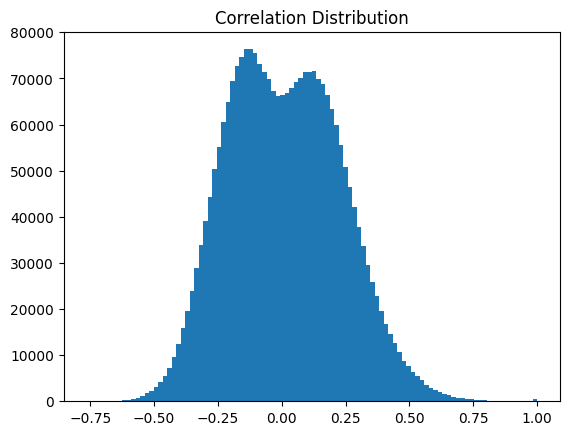

In [ ]:
import matplotlib.pyplot as plt

plt.hist(corr_tf_gene.flatten(), bins=100)
plt.title("Correlation Distribution")
plt.show()

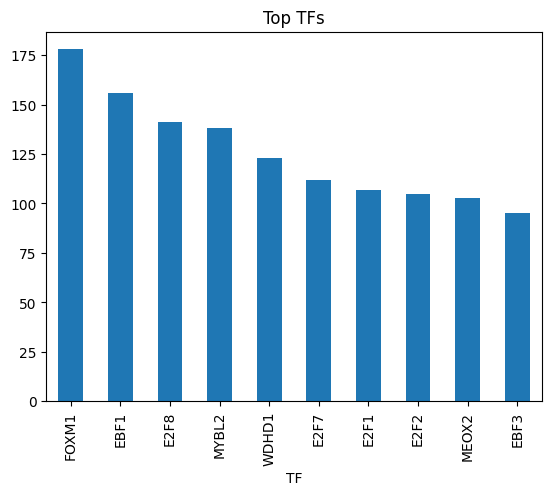

In [ ]:
top_tfs = edges_df["TF"].value_counts().head(10)

top_tfs.plot(kind="bar")
plt.title("Top TFs")
plt.show()

Small Network Plot

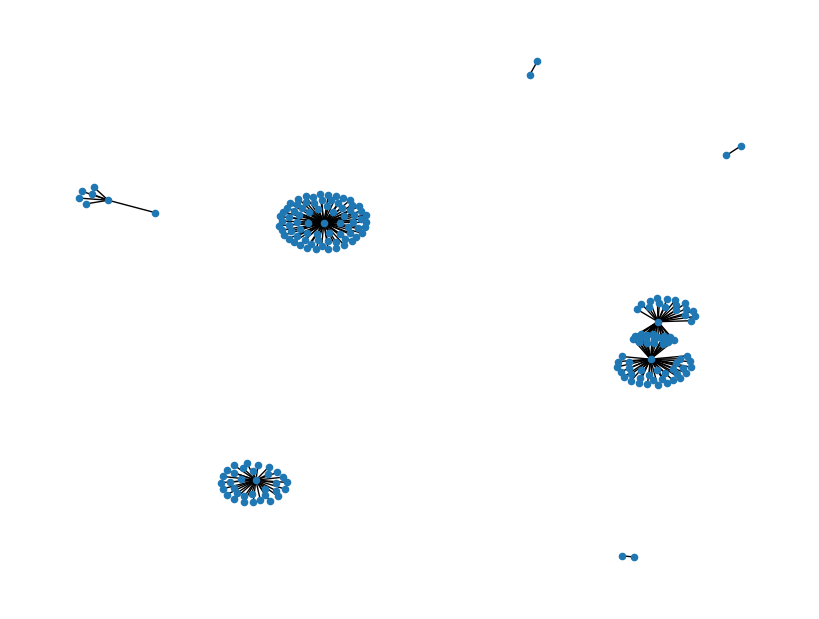

In [ ]:
import networkx as nx

sample = edges_df.head(200)

G = nx.from_pandas_edgelist(sample, "TF", "Target")

plt.figure(figsize=(8,6))
nx.draw(G, node_size=20)
plt.show()

Correlation assumes:

TF1 ↔ Gene

But real biology:

Gene = TF1 + TF2 + TF3 + ...
🚨 So Network Is:

Fast	✅
Interpretable	✅
Biologically complete	❌

Correlation Problem
Cannot model multiple TF influence
Produces too many edges

1.   Cannot model multiple TF influence

2.  Includes indirect relationships

3. Produces too many edges

This is why we move to regression, here we choose lasso regression

LASSO Advantage

For each gene:

Gene = w1*TF1 + w2*TF2 + ...

👉 And it keeps only:

Important TFs (others → 0)